# Phase 2: Data Preparation

**Thesis:** Hybrid Ensemble Learning for Proactive Resource Prediction in Kubernetes

**Dataset:** Alibaba Cluster Trace 2018

---

This notebook prepares data for ML training:
1. Load Phase 1 sampled data
2. Reclassify containers with corrected tier criteria
3. Resample irregular time series to regular intervals (using **FORWARD-FILL**)
4. Perform workload clustering
5. Create **TEMPORAL** train/val/test splits (chronological, not random)

### Important Fixes
- Uses **forward-fill** (not linear interpolation) to prevent future data leakage
- Tier criteria are internally consistent
- Temporal split ensures `train < val < test` in time

> ⚠️ This script does NOT do feature engineering. Feature engineering is handled in Phase 3 with proper lag constraints.

## Setup & Mount Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install dependencies (if needed)
!pip install -q scikit-learn pandas numpy

In [ ]:
import os
import gc
import json
import time
import warnings
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Configuration

Update the paths below to match your Google Drive folder structure.

In [ ]:
# =============================================================================
# Configuration
# =============================================================================

# >>> UPDATE THESE PATHS TO MATCH YOUR GOOGLE DRIVE <<<
DRIVE_BASE = '/content/drive/MyDrive/Thesis'  # Change this to your folder

CONFIG = {
    # Input from Phase 1
    'phase1_dir': f'{DRIVE_BASE}/phase1_output',
    'sampled_data': f'{DRIVE_BASE}/phase1_output/sampled_data.csv',
    'container_stats': f'{DRIVE_BASE}/phase1_output/container_stats.csv',

    # Output
    'output_dir': f'{DRIVE_BASE}/phase2_output',

    # Resampling settings
    'target_interval_seconds': 300,  # 5-minute intervals
    'min_sequence_length': 50,       # Minimum records for ML after resampling

    # Clustering settings
    'n_workload_clusters': 5,

    # Temporal split ratios
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,

    # Tier criteria - FIXED for internal consistency
    # At 5-min intervals: 1 day = 288 records, 7 days = 2016 records
    'tier_criteria': {
        1: {
            'name': 'EXCELLENT',
            'min_lifespan_hours': 168,  # 7 days
            'min_records': 1700,        # ~85% of max possible in 7 days
            'min_completeness': 0.85,
        },
        2: {
            'name': 'VERY_GOOD',
            'min_lifespan_hours': 120,  # 5 days
            'min_records': 1000,        # ~70% of max possible in 5 days
            'min_completeness': 0.70,
        },
        3: {
            'name': 'GOOD',
            'min_lifespan_hours': 72,   # 3 days
            'min_records': 500,         # ~60% of max possible in 3 days
            'min_completeness': 0.60,
        },
        4: {
            'name': 'FAIR',
            'min_lifespan_hours': 24,   # 1 day
            'min_records': 140,         # ~50% of max possible in 1 day
            'min_completeness': 0.50,
        },
        5: {
            'name': 'MARGINAL',
            'min_lifespan_hours': 6,    # 6 hours
            'min_records': 30,          # ~40% of max possible in 6 hours
            'min_completeness': 0.40,
        },
    },

    'random_seed': 42,
}

print("Configuration loaded!")
print(f"Input dir: {CONFIG['phase1_dir']}")
print(f"Output dir: {CONFIG['output_dir']}")

Configuration loaded!
Input dir: /content/drive/MyDrive/Thesis/phase1_output
Output dir: /content/drive/MyDrive/Thesis/phase2_output


## Utility Functions

In [ ]:
# =============================================================================
# Utility functions
# =============================================================================

def get_timestamp():
    return datetime.now().strftime('%H:%M:%S')

def log(msg):
    print(f"[{get_timestamp()}] {msg}")

def format_number(n):
    if n >= 1000000:
        return f"{n / 1000000:.1f}M"
    elif n >= 1000:
        return f"{n / 1000:.1f}K"
    return f"{int(n):,}"

def save_json(data, filepath):
    with open(filepath, 'w') as f:
        json.dump(data, f, indent=2, default=str)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def create_output_dirs():
    dirs = [
        CONFIG['output_dir'],
        f"{CONFIG['output_dir']}/data",
        f"{CONFIG['output_dir']}/clusters",
        f"{CONFIG['output_dir']}/ml_ready",
        f"{CONFIG['output_dir']}/reports",
    ]
    for d in dirs:
        ensure_dir(d)
    log("Output directories created.")

print("Utility functions defined!")

Utility functions defined!


---
## Step 1: Load Data from Phase 1

In [ ]:
def load_data():
    """Load data from Phase 1."""
    print("\n" + "=" * 70)
    print("STEP 1: Load Data from Phase 1")
    print("=" * 70)

    results = {}

    # Load sampled data
    sample_path = CONFIG['sampled_data']
    if not os.path.exists(sample_path):
        log(f"ERROR: {sample_path} not found")
        log("Run Phase 1 first or check your path configuration.")
        return None, None, results

    df = pd.read_csv(sample_path)
    log(f"Loaded sampled data: {len(df):,} rows")

    # Load container stats
    stats_path = CONFIG['container_stats']
    container_stats = None
    if os.path.exists(stats_path):
        container_stats = pd.read_csv(stats_path, index_col=0)
        log(f"Loaded container stats: {len(container_stats):,} containers")
    else:
        log("Container stats not found, will recompute")

    results['rows_loaded'] = len(df)
    results['containers_loaded'] = df['container_id'].nunique()

    log(f"Total rows: {format_number(len(df))}")
    log(f"Unique containers: {format_number(df['container_id'].nunique())}")

    return df, container_stats, results

---
## Step 2: Reclassify Containers

In [ ]:
def reclassify_containers(df, container_stats):
    """Reclassify containers with consistent tier criteria."""
    print("\n" + "=" * 70)
    print("STEP 2: Reclassify Containers")
    print("=" * 70)

    results = {}

    log("Tier criteria (corrected for consistency):")
    for tier, c in CONFIG['tier_criteria'].items():
        log(f"  Tier {tier} ({c['name']}): >={c['min_records']} records, "
            f">={c['min_lifespan_hours']}h, >={c['min_completeness']*100:.0f}% completeness")

    # Recompute container stats if needed
    if container_stats is None or 'record_count' not in container_stats.columns:
        log("Computing container statistics...")
        container_stats = df.groupby('container_id').agg({
            'time_stamp': ['count', 'min', 'max'],
            'cpu_util_percent': lambda x: x.notna().mean(),
            'mem_util_percent': lambda x: x.notna().mean(),
        })
        container_stats.columns = ['record_count', 'min_ts', 'max_ts', 'cpu_completeness', 'mem_completeness']
        container_stats['lifespan_hours'] = (container_stats['max_ts'] - container_stats['min_ts']) / 3600

    # Handle different column names from Phase 1
    if 'record_count' not in container_stats.columns and 'ts_max' in container_stats.columns:
        container_stats['record_count'] = df.groupby('container_id').size()

    if 'lifespan_hours' not in container_stats.columns:
        if 'ts_max' in container_stats.columns and 'ts_min' in container_stats.columns:
            container_stats['lifespan_hours'] = (container_stats['ts_max'] - container_stats['ts_min']) / 3600
        elif 'lifespan_days' in container_stats.columns:
            container_stats['lifespan_hours'] = container_stats['lifespan_days'] * 24

    # Compute completeness if not present
    if 'cpu_completeness' not in container_stats.columns:
        completeness = df.groupby('container_id').agg({
            'cpu_util_percent': lambda x: x.notna().mean(),
            'mem_util_percent': lambda x: x.notna().mean(),
        })
        completeness.columns = ['cpu_completeness', 'mem_completeness']
        container_stats = container_stats.join(completeness)

    # Classification function
    def classify_container(row):
        lifespan = row.get('lifespan_hours', 0)
        records = row.get('record_count', 0)
        cpu_comp = row.get('cpu_completeness', 0.5)
        mem_comp = row.get('mem_completeness', 0.5)

        # Handle NaN
        if pd.isna(lifespan): lifespan = 0
        if pd.isna(records): records = 0
        if pd.isna(cpu_comp): cpu_comp = 0.5
        if pd.isna(mem_comp): mem_comp = 0.5

        avg_comp = (cpu_comp + mem_comp) / 2

        for tier in [1, 2, 3, 4, 5]:
            c = CONFIG['tier_criteria'][tier]
            if (lifespan >= c['min_lifespan_hours'] and
                records >= c['min_records'] and
                avg_comp >= c['min_completeness']):
                return tier
        return 0  # UNSUITABLE

    log("Classifying containers...")
    container_stats['tier'] = container_stats.apply(classify_container, axis=1)

    # Count by tier
    tier_counts = container_stats['tier'].value_counts().to_dict()

    results['tier_counts'] = {}
    for tier in [0, 1, 2, 3, 4, 5]:
        name = CONFIG['tier_criteria'].get(tier, {}).get('name', 'UNSUITABLE')
        count = tier_counts.get(tier, 0)
        results['tier_counts'][f'tier{tier}'] = count

    # Calculate pools
    results['pools'] = {
        'primary': sum(tier_counts.get(t, 0) for t in [1, 2, 3]),
        'extended': sum(tier_counts.get(t, 0) for t in [1, 2, 3, 4]),
        'full': sum(tier_counts.get(t, 0) for t in [1, 2, 3, 4, 5]),
    }

    log("Tier distribution:")
    for tier in [1, 2, 3, 4, 5, 0]:
        name = CONFIG['tier_criteria'].get(tier, {}).get('name', 'UNSUITABLE')
        count = tier_counts.get(tier, 0)
        pct = count / len(container_stats) * 100 if len(container_stats) > 0 else 0
        log(f"  Tier {tier} ({name}): {count:,} ({pct:.1f}%)")

    log(f"Primary ML Pool (Tiers 1-3): {results['pools']['primary']:,}")
    log(f"Extended ML Pool (Tiers 1-4): {results['pools']['extended']:,}")

    # Save
    stats_path = f"{CONFIG['output_dir']}/data/container_stats_classified.csv"
    container_stats.to_csv(stats_path)
    log(f"Saved: {stats_path}")

    return container_stats, results

---
## Step 3: Time-Series Resampling (Forward-Fill)

**CRITICAL FIX:** Uses forward-fill (last observation carried forward) instead of linear interpolation to prevent future data leakage.

Linear interpolation uses both past AND future values, which means resampled "historical" points contain future information. Forward-fill only uses past values, which is safe.

In [ ]:
def resample_timeseries(df, container_stats):
    """
    Resample irregular time series to regular intervals.

    CRITICAL FIX: Uses forward-fill (last observation carried forward)
    instead of linear interpolation to prevent future data leakage.
    """
    print("\n" + "=" * 70)
    print("STEP 3: Time-Series Resampling (Forward-Fill)")
    print("=" * 70)

    results = {
        'target_interval_seconds': CONFIG['target_interval_seconds'],
        'method': 'forward_fill',  # NOT linear interpolation
    }

    target_interval = CONFIG['target_interval_seconds']
    log(f"Target interval: {target_interval}s ({target_interval / 60:.1f} minutes)")
    log("Method: Forward-fill (last observation carried forward)")
    log("Reason: Linear interpolation would leak future information")

    # Select eligible containers (Tier 1-4)
    eligible_tiers = [1, 2, 3, 4]
    if 'tier' in container_stats.columns:
        eligible_containers = container_stats[container_stats['tier'].isin(eligible_tiers)].index.tolist()
    else:
        eligible_containers = container_stats[container_stats['record_count'] >= 20].index.tolist()

    log(f"Eligible containers: {len(eligible_containers):,}")

    # Limit for memory
    max_containers = 5000
    if len(eligible_containers) > max_containers:
        np.random.seed(CONFIG['random_seed'])
        eligible_containers = np.random.choice(eligible_containers, max_containers, replace=False).tolist()
        log(f"Limited to {max_containers} containers for memory")

    resampled_data = []
    success_count = 0
    skip_count = 0

    log("Resampling time series...")

    for i, container_id in enumerate(eligible_containers):
        if (i + 1) % 500 == 0:
            log(f"  Processed {i + 1}/{len(eligible_containers)} containers")

        cdata = df[df['container_id'] == container_id].copy()
        if len(cdata) < 10:
            skip_count += 1
            continue

        cdata = cdata.sort_values('time_stamp')
        min_ts = cdata['time_stamp'].min()
        max_ts = cdata['time_stamp'].max()

        # Create regular time grid
        regular_times = np.arange(min_ts, max_ts + 1, target_interval)

        if len(regular_times) < CONFIG['min_sequence_length']:
            skip_count += 1
            continue

        try:
            resampled = pd.DataFrame({'time_stamp': regular_times})
            resampled['container_id'] = container_id

            # Get machine_id
            if 'machine_id' in cdata.columns:
                mode_machine = cdata['machine_id'].mode()
                resampled['machine_id'] = mode_machine.iloc[0] if len(mode_machine) > 0 else 'unknown'

            # FIXED: Use forward-fill via merge_asof with direction='backward'
            # This only uses past values, never future values
            for col in ['cpu_util_percent', 'mem_util_percent', 'disk_io_percent', 'net_in', 'net_out']:
                if col not in cdata.columns:
                    continue

                valid_data = cdata[cdata[col].notna()][['time_stamp', col]].copy()
                valid_data = valid_data.sort_values('time_stamp')

                if len(valid_data) >= 1:
                    # merge_asof with direction='backward' only uses past values
                    merged = pd.merge_asof(
                        resampled[['time_stamp']],
                        valid_data,
                        on='time_stamp',
                        direction='backward'  # CRITICAL: only use past values
                    )
                    resampled[col] = merged[col]
                else:
                    resampled[col] = np.nan

            # Clip to valid ranges
            for col in ['cpu_util_percent', 'mem_util_percent', 'disk_io_percent']:
                if col in resampled.columns:
                    resampled[col] = resampled[col].clip(0, 100)

            resampled_data.append(resampled)
            success_count += 1

        except Exception as e:
            skip_count += 1
            continue

    log("Combining resampled data...")
    df_resampled = pd.concat(resampled_data, ignore_index=True)

    avg_seq_len = len(df_resampled) / success_count if success_count > 0 else 0

    results['containers_processed'] = success_count
    results['containers_skipped'] = skip_count
    results['total_resampled_rows'] = len(df_resampled)
    results['avg_sequence_length'] = round(avg_seq_len, 1)

    log(f"Successfully resampled: {success_count:,} containers")
    log(f"Skipped (too short): {skip_count:,} containers")
    log(f"Total resampled rows: {format_number(len(df_resampled))}")
    log(f"Avg sequence length: {avg_seq_len:.1f} timesteps")

    # Verify regularity
    if len(df_resampled) > 0:
        sample_container = df_resampled['container_id'].iloc[0]
        sample_data = df_resampled[df_resampled['container_id'] == sample_container]
        sample_intervals = np.diff(sample_data['time_stamp'].values)
        if len(sample_intervals) > 0:
            interval_std = np.std(sample_intervals)
            results['interval_verification'] = {
                'mean_interval': float(np.mean(sample_intervals)),
                'std_interval': float(interval_std),
                'is_regular': interval_std < 1.0,
            }
            log(f"Interval verification: mean={np.mean(sample_intervals):.1f}s, std={interval_std:.4f}s")

    # Save
    output_path = f"{CONFIG['output_dir']}/data/resampled_data.csv"
    df_resampled.to_csv(output_path, index=False)
    log(f"Saved: {output_path}")

    return df_resampled, results

---
## Step 4: Workload Clustering

In [ ]:
def cluster_workloads(df_resampled, container_stats):
    """Cluster containers by workload patterns."""
    print("\n" + "=" * 70)
    print("STEP 4: Workload Clustering")
    print("=" * 70)

    results = {}

    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    log("Computing workload features...")

    container_features = df_resampled.groupby('container_id').agg({
        'cpu_util_percent': ['mean', 'std', 'min', 'max'],
        'mem_util_percent': ['mean', 'std', 'min', 'max'],
    })
    container_features.columns = [
        'cpu_mean', 'cpu_std', 'cpu_min', 'cpu_max',
        'mem_mean', 'mem_std', 'mem_min', 'mem_max',
    ]

    # Derived features
    container_features['cpu_range'] = container_features['cpu_max'] - container_features['cpu_min']
    container_features['mem_range'] = container_features['mem_max'] - container_features['mem_min']
    container_features['cpu_cv'] = container_features['cpu_std'] / container_features['cpu_mean'].clip(lower=0.1)
    container_features['mem_cv'] = container_features['mem_std'] / container_features['mem_mean'].clip(lower=0.1)

    # Handle NaN/inf
    container_features = container_features.replace([np.inf, -np.inf], np.nan)
    container_features = container_features.dropna()

    log(f"Containers with valid features: {len(container_features):,}")

    if len(container_features) < CONFIG['n_workload_clusters']:
        log("WARNING: Not enough containers for clustering")
        return container_stats, None, {'status': 'insufficient_data'}

    # Features for clustering
    feature_cols = ['cpu_mean', 'cpu_std', 'cpu_range', 'mem_mean', 'mem_std', 'mem_range']
    X = container_features[feature_cols].values

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means
    n_clusters = CONFIG['n_workload_clusters']
    log(f"Running K-Means with {n_clusters} clusters...")

    kmeans = KMeans(n_clusters=n_clusters, random_state=CONFIG['random_seed'], n_init=10)
    container_features['cluster_id'] = kmeans.fit_predict(X_scaled)

    # Analyze clusters
    cluster_profiles = []
    cluster_names = {}

    log("Workload cluster profiles:")
    for cluster_id in range(n_clusters):
        cluster_data = container_features[container_features['cluster_id'] == cluster_id]

        profile = {
            'cluster_id': cluster_id,
            'count': len(cluster_data),
            'percent': round(len(cluster_data) / len(container_features) * 100, 1),
            'cpu_mean': round(cluster_data['cpu_mean'].mean(), 2),
            'cpu_std': round(cluster_data['cpu_std'].mean(), 2),
            'mem_mean': round(cluster_data['mem_mean'].mean(), 2),
            'mem_std': round(cluster_data['mem_std'].mean(), 2),
        }

        # Name cluster based on characteristics
        if profile['cpu_std'] > 15 or profile['mem_std'] > 15:
            name = 'VOLATILE'
        elif profile['cpu_mean'] > 50:
            name = 'CPU_HEAVY'
        elif profile['mem_mean'] > 70:
            name = 'MEM_HEAVY'
        elif profile['cpu_mean'] < 10 and profile['mem_mean'] < 30:
            name = 'IDLE'
        else:
            name = 'BALANCED'

        profile['name'] = name
        cluster_names[cluster_id] = name
        cluster_profiles.append(profile)

        log(f"  Cluster {cluster_id} ({name}): {profile['count']:,} ({profile['percent']:.1f}%)")
        log(f"    CPU: {profile['cpu_mean']:.1f}% +/- {profile['cpu_std']:.1f}%")
        log(f"    MEM: {profile['mem_mean']:.1f}% +/- {profile['mem_std']:.1f}%")

    results['n_clusters'] = n_clusters
    results['cluster_profiles'] = cluster_profiles
    results['cluster_names'] = cluster_names
    results['containers_clustered'] = len(container_features)

    # Add cluster info
    container_features['workload_cluster'] = container_features['cluster_id'].map(cluster_names)

    # Merge to container_stats
    if container_stats is not None:
        container_stats = container_stats.join(
            container_features[['cluster_id', 'workload_cluster']],
            how='left'
        )
        # Fill missing with -1 and UNKNOWN
        container_stats['cluster_id'] = container_stats['cluster_id'].fillna(-1).astype(int)
        container_stats['workload_cluster'] = container_stats['workload_cluster'].fillna('UNKNOWN')

    # Save
    output_path = f"{CONFIG['output_dir']}/clusters/container_clusters.csv"
    container_features.to_csv(output_path)
    log(f"Saved: {output_path}")

    return container_stats, container_features, results

---
## Step 5: Temporal Train/Val/Test Split

This is a **CHRONOLOGICAL** split, not random:
- Train data comes BEFORE validation data
- Validation data comes BEFORE test data

This prevents data leakage from future information.

In [ ]:
def temporal_split(df_resampled, container_features):
    """
    Create TEMPORAL train/val/test splits.

    This is a CHRONOLOGICAL split, not random.
    Train data comes BEFORE validation data.
    Validation data comes BEFORE test data.

    This prevents data leakage from future information.
    """
    print("\n" + "=" * 70)
    print("STEP 5: Temporal Train/Val/Test Split")
    print("=" * 70)

    results = {}

    log("Using TEMPORAL (chronological) split")
    log("  Train data comes BEFORE validation data")
    log("  Validation data comes BEFORE test data")

    # Sort by time
    df_sorted = df_resampled.sort_values('time_stamp').reset_index(drop=True)

    # Time range
    min_time = df_sorted['time_stamp'].min()
    max_time = df_sorted['time_stamp'].max()
    time_range = max_time - min_time

    log(f"Time range: {time_range / 3600:.1f} hours")

    # Split points by time
    train_end_time = min_time + time_range * CONFIG['train_ratio']
    val_end_time = min_time + time_range * (CONFIG['train_ratio'] + CONFIG['val_ratio'])

    # Split
    df_train = df_sorted[df_sorted['time_stamp'] < train_end_time].copy()
    df_val = df_sorted[
        (df_sorted['time_stamp'] >= train_end_time) &
        (df_sorted['time_stamp'] < val_end_time)
    ].copy()
    df_test = df_sorted[df_sorted['time_stamp'] >= val_end_time].copy()

    # Add cluster info
    if container_features is not None and 'cluster_id' in container_features.columns:
        cluster_info = container_features[['cluster_id', 'workload_cluster']]
        for split_df in [df_train, df_val, df_test]:
            # Safe merge that handles missing containers
            merged = split_df[['container_id']].merge(
                cluster_info.reset_index(),
                on='container_id',
                how='left'
            )
            split_df['cluster_id'] = merged['cluster_id'].fillna(-1).astype(int).values
            split_df['workload_cluster'] = merged['workload_cluster'].fillna('UNKNOWN').values

    # Verify no temporal overlap
    train_max = df_train['time_stamp'].max()
    val_min = df_val['time_stamp'].min()
    val_max = df_val['time_stamp'].max()
    test_min = df_test['time_stamp'].min()

    is_valid = (train_max < val_min) and (val_max < test_min)

    if is_valid:
        log("✓ VERIFIED: No temporal overlap between splits")
    else:
        log("⚠ WARNING: Temporal overlap detected!")

    results['temporal_verification'] = {
        'train_max': int(train_max),
        'val_min': int(val_min),
        'val_max': int(val_max),
        'test_min': int(test_min),
        'is_valid': is_valid,
    }

    results['splits'] = {
        'train': {
            'rows': len(df_train),
            'containers': df_train['container_id'].nunique(),
        },
        'val': {
            'rows': len(df_val),
            'containers': df_val['container_id'].nunique(),
        },
        'test': {
            'rows': len(df_test),
            'containers': df_test['container_id'].nunique(),
        },
    }

    log("Dataset splits:")
    log(f"  Train: {len(df_train):,} rows, {df_train['container_id'].nunique():,} containers")
    log(f"  Val:   {len(df_val):,} rows, {df_val['container_id'].nunique():,} containers")
    log(f"  Test:  {len(df_test):,} rows, {df_test['container_id'].nunique():,} containers")

    # Cluster distribution
    if 'workload_cluster' in df_train.columns:
        log("Cluster distribution in splits:")
        for name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
            dist = split_df['workload_cluster'].value_counts(normalize=True)
            dist_str = ', '.join([f"{k}: {v * 100:.0f}%" for k, v in dist.head(3).items()])
            log(f"  {name}: {dist_str}")

    # Save
    log("Saving ML-ready datasets...")

    train_path = f"{CONFIG['output_dir']}/ml_ready/train.csv"
    df_train.to_csv(train_path, index=False)
    log(f"  Saved: {train_path}")

    val_path = f"{CONFIG['output_dir']}/ml_ready/val.csv"
    df_val.to_csv(val_path, index=False)
    log(f"  Saved: {val_path}")

    test_path = f"{CONFIG['output_dir']}/ml_ready/test.csv"
    df_test.to_csv(test_path, index=False)
    log(f"  Saved: {test_path}")

    return df_train, df_val, df_test, results

---
## Step 6: Generate Report

In [ ]:
def generate_report(all_results):
    """Generate Phase 2 summary report."""
    print("\n" + "=" * 70)
    print("STEP 6: Generate Report")
    print("=" * 70)

    lines = [
        "=" * 70,
        "PHASE 2: DATA PREPARATION REPORT",
        "=" * 70,
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "",
        "-" * 70,
        "KEY IMPROVEMENTS",
        "-" * 70,
        "",
        "1. FORWARD-FILL RESAMPLING (not linear interpolation)",
        "   - Linear interpolation uses future values (data leakage)",
        "   - Forward-fill only uses past values (safe)",
        "",
        "2. TEMPORAL SPLIT (not random)",
        "   - Train < Val < Test in time",
        "   - Prevents future information leakage",
        "",
        "3. CONSISTENT TIER CRITERIA",
        "   - min_records and min_completeness are now aligned",
        "",
    ]

    if 'resampling' in all_results:
        rs = all_results['resampling']
        lines.extend([
            "-" * 70,
            "RESAMPLING",
            "-" * 70,
            f"  Method: {rs.get('method', 'forward_fill')}",
            f"  Containers: {rs.get('containers_processed', 0):,}",
            f"  Rows: {rs.get('total_resampled_rows', 0):,}",
            "",
        ])

    if 'temporal_split' in all_results:
        ts = all_results['temporal_split']
        splits = ts.get('splits', {})
        lines.extend([
            "-" * 70,
            "TEMPORAL SPLIT",
            "-" * 70,
            f"  Train: {splits.get('train', {}).get('rows', 0):,} rows",
            f"  Val:   {splits.get('val', {}).get('rows', 0):,} rows",
            f"  Test:  {splits.get('test', {}).get('rows', 0):,} rows",
            f"  Valid: {ts.get('temporal_verification', {}).get('is_valid', False)}",
            "",
        ])

    lines.extend([
        "-" * 70,
        "OUTPUT FILES",
        "-" * 70,
        f"  {CONFIG['output_dir']}/ml_ready/train.csv",
        f"  {CONFIG['output_dir']}/ml_ready/val.csv",
        f"  {CONFIG['output_dir']}/ml_ready/test.csv",
        "",
        "-" * 70,
        "NEXT STEPS",
        "-" * 70,
        "  1. Files are already saved in Google Drive",
        "  2. Run Phase 3 on Google Colab (GPU recommended)",
        "",
        "=" * 70,
    ])

    report_text = "\n".join(lines)

    report_path = f"{CONFIG['output_dir']}/reports/phase2_report.txt"
    with open(report_path, 'w') as f:
        f.write(report_text)
    log(f"Saved: {report_path}")

    print("\n" + report_text)

    return report_text

---
## 🚀 Run All Steps

In [ ]:
def main():
    start_time = time.time()

    print("\n" + "=" * 70)
    print("PHASE 2: DATA PREPARATION")
    print("With forward-fill resampling and temporal split")
    print("=" * 70)

    create_output_dirs()

    all_results = {
        'generated': datetime.now().isoformat(),
    }

    # Step 1: Load data
    df, container_stats, load_results = load_data()
    if df is None:
        return None
    all_results['load'] = load_results

    # Step 2: Reclassify containers
    container_stats, reclass_results = reclassify_containers(df, container_stats)
    all_results['reclassification'] = reclass_results

    # Step 3: Resample time series
    df_resampled, resample_results = resample_timeseries(df, container_stats)
    all_results['resampling'] = resample_results

    # Free memory
    del df
    gc.collect()

    # Step 4: Cluster workloads
    container_stats, container_features, cluster_results = cluster_workloads(df_resampled, container_stats)
    all_results['clustering'] = cluster_results

    # Step 5: Temporal split
    df_train, df_val, df_test, split_results = temporal_split(df_resampled, container_features)
    all_results['temporal_split'] = split_results

    # Save master results
    results_path = f"{CONFIG['output_dir']}/reports/phase2_results.json"
    save_json(all_results, results_path)
    log(f"Saved: {results_path}")

    # Step 6: Generate report
    generate_report(all_results)

    elapsed = time.time() - start_time

    print("\n" + "=" * 70)
    print("✅ PHASE 2 COMPLETE")
    print("=" * 70)
    print(f"""
Output: {CONFIG['output_dir']}
Processing time: {elapsed / 60:.1f} minutes

Next steps:
  1. Files are saved in Google Drive
  2. Run Phase 3 notebook (GPU recommended)
""")

    return all_results

In [ ]:
# Run the pipeline
results = main()


PHASE 2: DATA PREPARATION
With forward-fill resampling and temporal split
[08:54:49] Output directories created.

STEP 1: Load Data from Phase 1
[08:55:22] Loaded sampled data: 40,155,500 rows
[08:55:23] Loaded container stats: 67,436 containers
[08:55:25] Total rows: 40.2M
[08:55:27] Unique containers: 67.4K

STEP 2: Reclassify Containers
[08:55:27] Tier criteria (corrected for consistency):
[08:55:27]   Tier 1 (EXCELLENT): >=1700 records, >=168h, >=85% completeness
[08:55:27]   Tier 2 (VERY_GOOD): >=1000 records, >=120h, >=70% completeness
[08:55:27]   Tier 3 (GOOD): >=500 records, >=72h, >=60% completeness
[08:55:27]   Tier 4 (FAIR): >=140 records, >=24h, >=50% completeness
[08:55:27]   Tier 5 (MARGINAL): >=30 records, >=6h, >=40% completeness
[08:55:42] Classifying containers...
[08:55:42] Tier distribution:
[08:55:42]   Tier 1 (EXCELLENT): 0 (0.0%)
[08:55:42]   Tier 2 (VERY_GOOD): 0 (0.0%)
[08:55:42]   Tier 3 (GOOD): 59,598 (88.4%)
[08:55:42]   Tier 4 (FAIR): 6,413 (9.5%)
[08:55:

---
## 📊 Quick Data Inspection (Optional)

In [ ]:
# Optional: Inspect the output data
import pandas as pd

train_path = f"{CONFIG['output_dir']}/ml_ready/train.csv"
if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    print("Train data shape:", df_train.shape)
    print("\nColumns:", df_train.columns.tolist())
    print("\nSample:")
    display(df_train.head())
    print("\nStatistics:")
    display(df_train.describe())
else:
    print("Train data not found. Run the main() function first.")

Train data shape: (7413073, 10)

Columns: ['time_stamp', 'container_id', 'machine_id', 'cpu_util_percent', 'mem_util_percent', 'disk_io_percent', 'net_in', 'net_out', 'cluster_id', 'workload_cluster']

Sample:


,time_stamp,container_id,machine_id,cpu_util_percent,mem_util_percent,disk_io_percent,net_in,net_out,cluster_id,workload_cluster
0,86400,c_52834,m_2408,4.0,71.0,5.0,0.01,0.01,0,BALANCED
1,86400,c_28985,m_2577,2.0,84.0,2.0,0.03,0.03,4,MEM_HEAVY
2,86400,c_9142,m_2656,5.0,99.0,1.0,0.01,0.02,4,MEM_HEAVY
3,86400,c_49690,m_3727,18.0,99.0,5.0,0.08,0.12,2,MEM_HEAVY
4,86400,c_52446,m_1945,21.0,100.0,3.0,1.32,1.69,2,MEM_HEAVY



Statistics:


,time_stamp,cpu_util_percent,mem_util_percent,disk_io_percent,net_in,net_out,cluster_id
count,7.413073e+06,7.413073e+06,7.413073e+06,7.388119e+06,7.413073e+06,7.413073e+06,7.413073e+06
mean,3.308312e+05,9.503735e+00,8.144195e+01,8.872553e+00,1.714022e-01,1.801136e-01,2.382254e+00
std,1.394729e+05,1.037417e+01,2.423797e+01,8.191819e+00,4.002903e-01,4.454983e-01,1.419920e+00
min,8.640000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.100400e+05,3.000000e+00,6.900000e+01,5.000000e+00,1.000000e-02,1.000000e-02,2.000000e+00
50%,3.310500e+05,6.000000e+00,9.500000e+01,7.000000e+00,4.000000e-02,5.000000e-02,3.000000e+00
75%,4.519500e+05,1.300000e+01,9.900000e+01,1.000000e+01,1.600000e-01,1.700000e-01,4.000000e+00
max,5.702300e+05,1.000000e+02,1.000000e+02,1.000000e+02,1.864000e+01,2.301000e+01,4.000000e+00


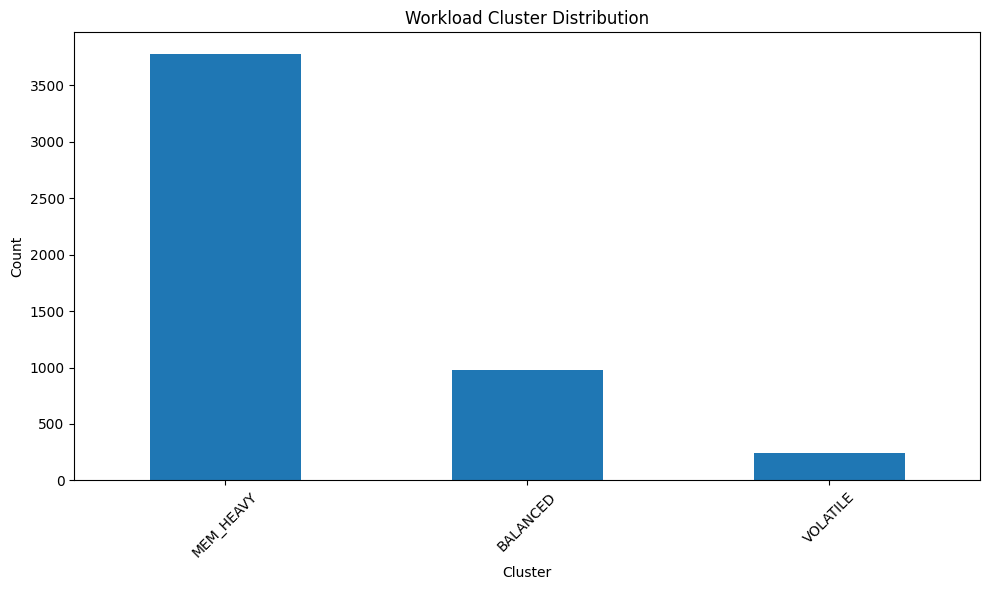

In [ ]:
# Optional: Visualize cluster distribution
import matplotlib.pyplot as plt

clusters_path = f"{CONFIG['output_dir']}/clusters/container_clusters.csv"
if os.path.exists(clusters_path):
    clusters_df = pd.read_csv(clusters_path)

    if 'workload_cluster' in clusters_df.columns:
        fig, ax = plt.subplots(figsize=(10, 6))
        clusters_df['workload_cluster'].value_counts().plot(kind='bar', ax=ax)
        ax.set_title('Workload Cluster Distribution')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Clusters data not found. Run the main() function first.")